# ✉️ Sales Prediction using Python

This project develops machine learning regression models to predict product sales based on the advertising budgets spent on three mediums: **TV, Radio, and Newspaper**.

## 📊 Dataset Features
- `TV`: Advertising budget spent on TV (in thousands of dollars).
- `Radio`: Advertising budget spent on Radio (in thousands of dollars).
- `Newspaper`: Advertising budget spent on Newspaper (in thousands of dollars).
- `Sales`: Sales of the product (Target Variable, in thousands of units).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

In [2]:
# Load the dataset
df = pd.read_csv("Advertising.csv")

# Display basic details
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (200, 5)


,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [3]:
# Check for missing values and description
print("--- Missing Values ---")
print(df.isnull().sum())

# Clean the dataset: drop the unnamed index column if it exists
unnamed_cols = [c for c in df.columns if 'Unnamed' in c or c == '']
if unnamed_cols:
    df = df.drop(columns=unnamed_cols)
elif df.columns[0] == df.columns[0] and df.iloc[:, 0].dtype == int and df.iloc[0, 0] == 1:
    # Sometimes index is the first column with empty string name
    df = df.drop(df.columns[0], axis=1)

print("\n--- Cleaned Columns ---")
print(df.columns.tolist())

print("\n--- Dataset Summary Description ---")
print(df.describe())

--- Missing Values ---
Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

--- Cleaned Columns ---
['TV', 'Radio', 'Newspaper', 'Sales']

--- Dataset Summary Description ---
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   14.022500
std     85.854236   14.846809   21.778621    5.217457
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   10.375000
50%    149.750000   22.900000   25.750000   12.900000
75%    218.825000   36.525000   45.100000   17.400000
max    296.400000   49.600000  114.000000   27.000000


## 📈 Exploratory Data Analysis (EDA)
Let's visualize the sales distribution and the relationship between each advertising medium and sales.

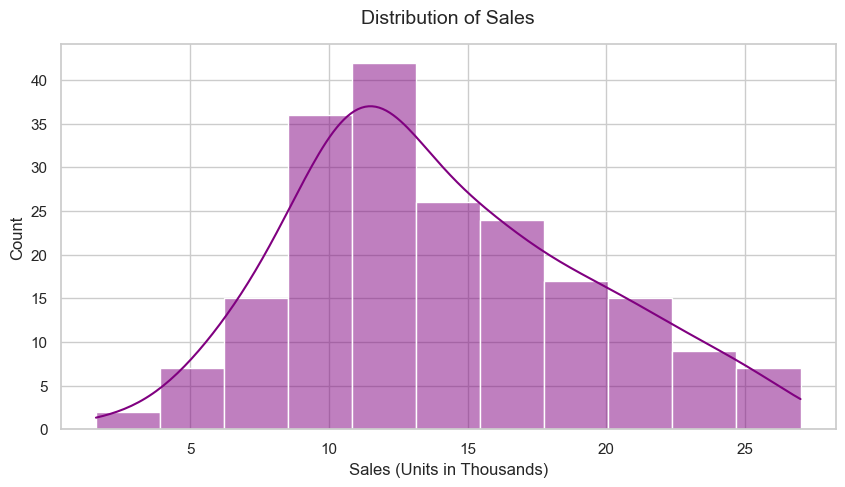

In [4]:
# 1. Distribution of Sales
plt.figure(figsize=(10, 5))
sns.histplot(df['Sales'], kde=True, color='purple')
plt.title("Distribution of Sales", fontsize=14, pad=15)
plt.xlabel("Sales (Units in Thousands)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.savefig("sales_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

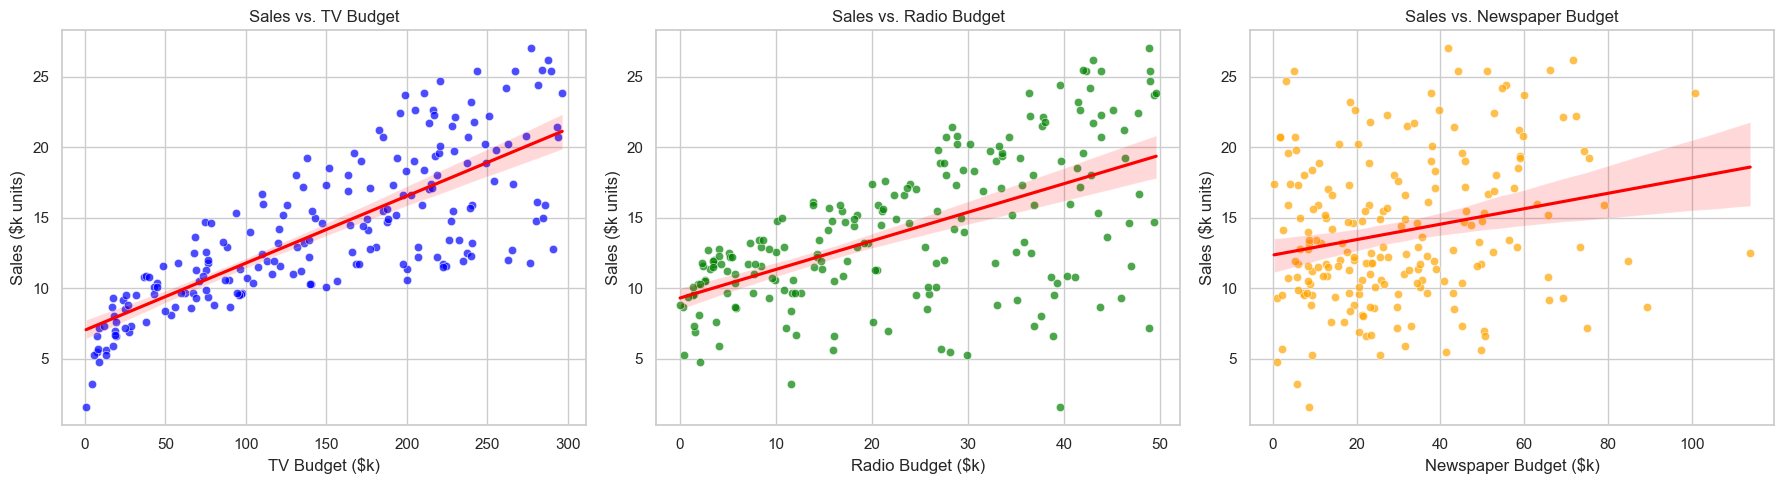

In [5]:
# 2. Relationship between Budgets and Sales
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
features = ['TV', 'Radio', 'Newspaper']
colors = ['blue', 'green', 'orange']

for i, feature in enumerate(features):
    sns.scatterplot(ax=axes[i], data=df, x=feature, y='Sales', color=colors[i], alpha=0.7)
    sns.regplot(ax=axes[i], data=df, x=feature, y='Sales', scatter=False, color='red')
    axes[i].set_title(f"Sales vs. {feature} Budget")
    axes[i].set_xlabel(f"{feature} Budget ($k)")
    axes[i].set_ylabel("Sales ($k units)")

plt.tight_layout()
plt.savefig("sales_vs_budgets.png", dpi=300, bbox_inches="tight")
plt.show()

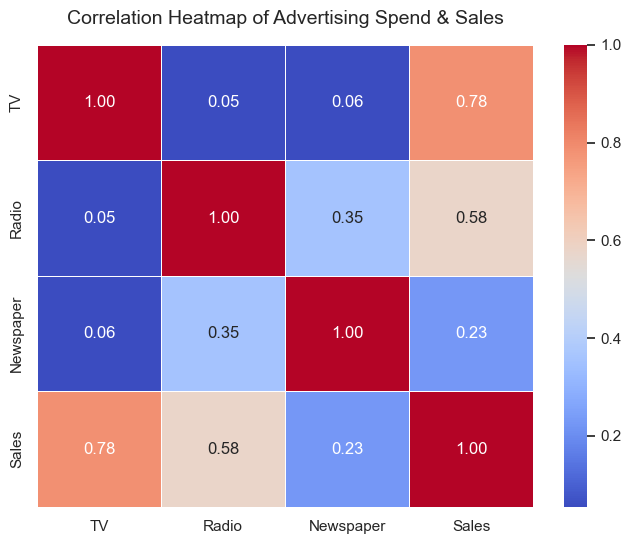

In [6]:
# 3. Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap of Advertising Spend & Sales", fontsize=14, pad=15)
plt.savefig("sales_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [7]:
# Splitting Features and Target
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# Split into Train & Test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 160
Testing set size: 40


## 🤖 Model Training & Comparison
We train and compare four models:
1. **Linear Regression**
2. **Decision Tree Regressor**
3. **Random Forest Regressor**
4. **Gradient Boosting Regressor**

In [8]:
# Initialize models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

# Dictionary to store metrics
metrics = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    metrics[name] = {"R2": r2, "MAE": mae, "RMSE": rmse}
    
    print(f"=== {name} ===")
    print(f"R2 Score:  {r2:.4f}")
    print(f"MAE:       {mae:.4f}")
    print(f"RMSE:      {rmse:.4f}")
    print("-" * 40)

=== Linear Regression ===
R2 Score:  0.8994
MAE:       1.4608
RMSE:      1.7816
----------------------------------------
=== Decision Tree ===
R2 Score:  0.9311
MAE:       0.9850
RMSE:      1.4748
----------------------------------------
=== Random Forest ===
R2 Score:  0.9813
MAE:       0.6201
RMSE:      0.7686
----------------------------------------
=== Gradient Boosting ===
R2 Score:  0.9831
MAE:       0.6187
RMSE:      0.7298
----------------------------------------


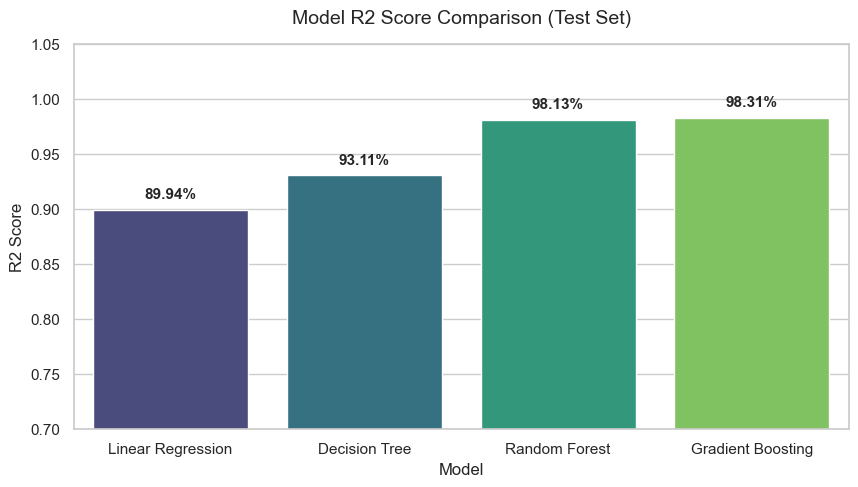

In [9]:
# Plot R2 score comparison
model_names = list(metrics.keys())
r2_scores = [metrics[name]["R2"] for name in model_names]

plt.figure(figsize=(10, 5))
sns.barplot(x=model_names, y=r2_scores, palette='viridis', hue=model_names, legend=False)
plt.ylim(0.7, 1.05)
plt.title("Model R2 Score Comparison (Test Set)", fontsize=14, pad=15)
plt.ylabel("R2 Score", fontsize=12)
plt.xlabel("Model", fontsize=12)

for i, val in enumerate(r2_scores):
    plt.text(i, val + 0.01, f"{val:.2%}", ha='center', fontweight='bold', fontsize=11)

plt.savefig("model_r2_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

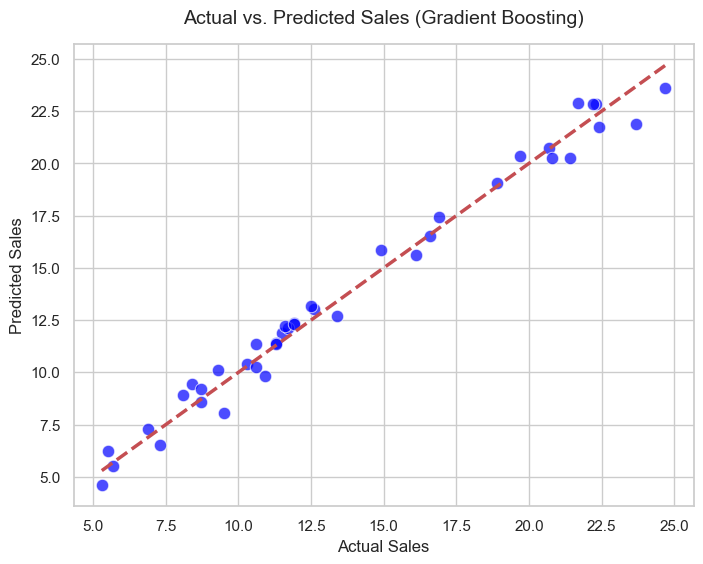

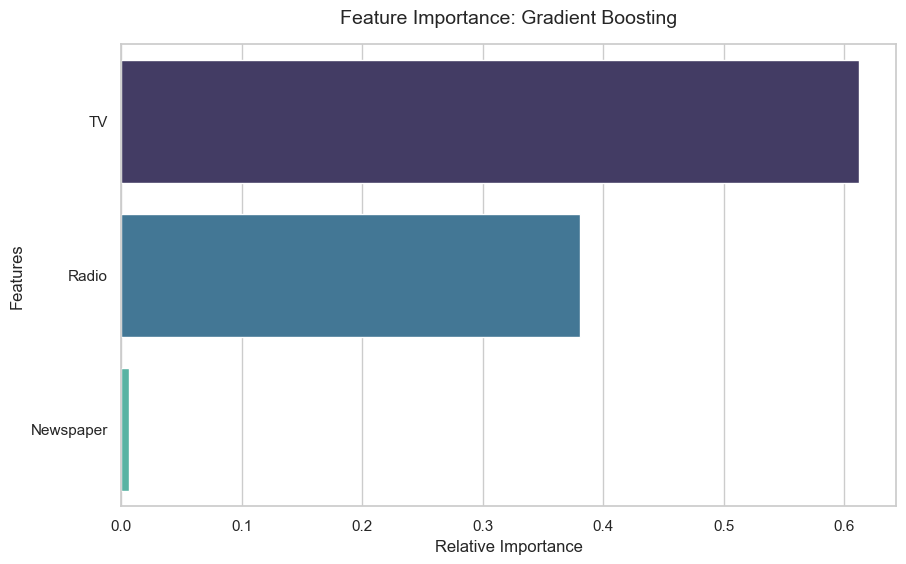

The best performing model on the test set is: Gradient Boosting with an R2 Score of 98.31%


In [10]:
# Find the best model based on R2 score
best_model_name = max(metrics, key=lambda name: metrics[name]["R2"])
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

# 1. Actual vs. Predicted Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_best, color='blue', alpha=0.7, s=80)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2.5)
plt.title(f"Actual vs. Predicted Sales ({best_model_name})", fontsize=14, pad=15)
plt.xlabel("Actual Sales", fontsize=12)
plt.ylabel("Predicted Sales", fontsize=12)
plt.savefig("actual_vs_predicted_sales.png", dpi=300, bbox_inches="tight")
plt.show()

# 2. Feature Importance for the best model
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=importances[indices], y=X.columns[indices], palette='mako', hue=X.columns[indices], legend=False)
    plt.title(f"Feature Importance: {best_model_name}", fontsize=14, pad=15)
    plt.xlabel("Relative Importance", fontsize=12)
    plt.ylabel("Features", fontsize=12)
    plt.savefig("best_model_feature_importance.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Feature importances are not available for this model.")

print(f"The best performing model on the test set is: {best_model_name} with an R2 Score of {metrics[best_model_name]['R2']:.2%}")